In [1]:
import pandas as pd
import regex as re

In [4]:
df = pd.read_csv('../data/raw/twitter_data.csv')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9485 entries, 0 to 9484
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   type                      9485 non-null   str    
 1   id                        9485 non-null   int64  
 2   url                       9485 non-null   str    
 3   twitterUrl                9485 non-null   str    
 4   text                      9485 non-null   str    
 5   source                    0 non-null      float64
 6   retweetCount              9485 non-null   int64  
 7   replyCount                9485 non-null   int64  
 8   likeCount                 9485 non-null   int64  
 9   quoteCount                9485 non-null   int64  
 10  viewCount                 9485 non-null   int64  
 11  createdAt                 9485 non-null   str    
 12  lang                      9485 non-null   str    
 13  bookmarkCount             9485 non-null   int64  
 14  isReply            

In [7]:
df.head()

,type,id,url,twitterUrl,text,source,retweetCount,replyCount,likeCount,quoteCount,...,card,place,entities,reply_to_user_results,quoted_tweet_results,quoted_tweet,retweeted_tweet,isConversationControlled,searchTermIndex,isQuote
0,tweet,2058239245148651767,https://x.com/ensivo/status/2058239245148651767,https://twitter.com/ensivo/status/205823924514...,kondisi negara udah bener bener diluar nalar\n...,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,NaN,NaN,False,0,NaN
1,tweet,2058239197652406671,https://x.com/natachaintikk/status/20582391976...,https://twitter.com/natachaintikk/status/20582...,ciecie joong jadi rupiah bgt didepan bininya 🤭...,NaN,0,0,0,0,...,NaN,{},{'media': [{'additional_media_info': {'monetiz...,NaN,NaN,NaN,NaN,False,0,NaN
2,tweet,2058239004710158506,https://x.com/3JSPACE/status/2058239004710158506,https://twitter.com/3JSPACE/status/20582390047...,membeli semua make up konser 0 rupiah karena c...,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,NaN,NaN,False,0,NaN
3,tweet,2058238886363668815,https://x.com/rainy_snowflake/status/205823888...,https://twitter.com/rainy_snowflake/status/205...,Nilai tukar rupiah gak disamain ma yen aja git...,NaN,0,1,0,0,...,NaN,{},{},NaN,NaN,NaN,NaN,False,0,NaN
4,tweet,2058238081271308426,https://x.com/zss0ur/status/2058238081271308426,https://twitter.com/zss0ur/status/205823808127...,aduh aku bacanya ikutan kaya rupiah,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,"{'type': 'tweet', 'id': '2058180601614946330',...",NaN,False,0,True


In [8]:
columns = [
    'id', 'url','text', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount',
    'viewCount', 'createdAt', 'lang', 'bookmarkCount'
    ]
df_cleaned = df.copy()
df_cleaned = df_cleaned[columns]

In [9]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 9485 entries, 0 to 9484
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             9485 non-null   int64
 1   url            9485 non-null   str  
 2   text           9485 non-null   str  
 3   retweetCount   9485 non-null   int64
 4   replyCount     9485 non-null   int64
 5   likeCount      9485 non-null   int64
 6   quoteCount     9485 non-null   int64
 7   viewCount      9485 non-null   int64
 8   createdAt      9485 non-null   str  
 9   lang           9485 non-null   str  
 10  bookmarkCount  9485 non-null   int64
dtypes: int64(7), str(4)
memory usage: 3.5 MB


In [10]:
df_cleaned['author'] = df_cleaned['url'].str.extract(r"x\.com/([^/']+)")
df_cleaned.drop(columns=['url'], inplace=True)

In [11]:
df_cleaned.head()

,id,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,lang,bookmarkCount,author
0,2058239245148651767,kondisi negara udah bener bener diluar nalar\n...,0,0,0,0,2,Sat May 23 17:30:50 +0000 2026,in,0,ensivo
1,2058239197652406671,ciecie joong jadi rupiah bgt didepan bininya 🤭...,0,0,0,0,2,Sat May 23 17:30:39 +0000 2026,in,0,natachaintikk
2,2058239004710158506,membeli semua make up konser 0 rupiah karena c...,0,0,0,0,0,Sat May 23 17:29:53 +0000 2026,in,0,3JSPACE
3,2058238886363668815,Nilai tukar rupiah gak disamain ma yen aja git...,0,1,0,0,2,Sat May 23 17:29:25 +0000 2026,in,0,rainy_snowflake
4,2058238081271308426,aduh aku bacanya ikutan kaya rupiah,0,0,0,0,3,Sat May 23 17:26:13 +0000 2026,in,0,zss0ur


In [12]:
df_cleaned['createdAt'].value_counts()

createdAt
Thu May 21 02:55:00 +0000 2026    11
Thu May 21 04:55:00 +0000 2026     9
Sat May 23 05:00:00 +0000 2026     7
Sat May 23 11:57:16 +0000 2026     3
Sat May 23 10:43:37 +0000 2026     3
                                  ..
Wed May 20 08:04:40 +0000 2026     1
Wed May 20 08:04:33 +0000 2026     1
Wed May 20 08:02:09 +0000 2026     1
Wed May 20 08:00:19 +0000 2026     1
Wed May 20 08:00:13 +0000 2026     1
Name: count, Length: 9220, dtype: int64

In [13]:
df_cleaned['createdAt'] = pd.to_datetime(df_cleaned['createdAt']).dt.date

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16408\531241427.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['createdAt'] = pd.to_datetime(df_cleaned['createdAt']).dt.date


In [14]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 9485 entries, 0 to 9484
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             9485 non-null   int64 
 1   text           9485 non-null   str   
 2   retweetCount   9485 non-null   int64 
 3   replyCount     9485 non-null   int64 
 4   likeCount      9485 non-null   int64 
 5   quoteCount     9485 non-null   int64 
 6   viewCount      9485 non-null   int64 
 7   createdAt      9485 non-null   object
 8   lang           9485 non-null   str   
 9   bookmarkCount  9485 non-null   int64 
 10  author         9485 non-null   str   
dtypes: int64(7), object(1), str(3)
memory usage: 2.9+ MB


In [15]:
df_cleaned = df_cleaned.drop(df_cleaned[df_cleaned['lang'] < 'en'].index)

In [16]:
df_cleaned['lang'].value_counts()

lang
in     9321
en      118
lt        8
tl        7
it        4
es        4
und       3
hi        3
qme       2
tr        2
ja        2
qht       2
eu        2
ht        2
ko        1
pl        1
Name: count, dtype: int64

In [17]:
df_cleaned = df_cleaned[df_cleaned['lang'] == 'in']
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned.drop(columns=['lang'], inplace=True)

In [18]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.dropna(inplace=True)

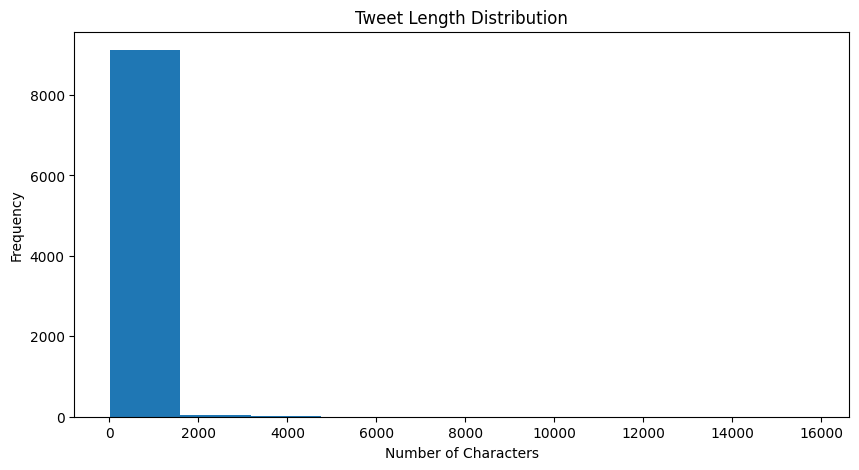

In [19]:
import matplotlib.pyplot as plt

# hitung panjang tweet (jumlah karakter)
df_cleaned["tweet_length"] = df_cleaned["text"].astype(str).apply(len)

plt.figure(figsize=(10,5))

plt.hist(
    df_cleaned["tweet_length"]
)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [20]:
print("Minimum:",df_cleaned["tweet_length"].min())
print("Maximum:",df_cleaned["tweet_length"].max())
print("Average:",df_cleaned["tweet_length"].mean())
print("Median:",df_cleaned["tweet_length"].median())

Minimum: 6
Maximum: 15836
Average: 217.06671745755332
Median: 176.0


In [21]:
df_cleaned["tweet_length"] = (df_cleaned["text"].astype(str).apply(len))

df_cleaned = df_cleaned[(df_cleaned["tweet_length"]>=15) &(df_cleaned["tweet_length"]<=500)]

In [22]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 8802 entries, 0 to 9320
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             8802 non-null   int64 
 1   text           8802 non-null   str   
 2   retweetCount   8802 non-null   int64 
 3   replyCount     8802 non-null   int64 
 4   likeCount      8802 non-null   int64 
 5   quoteCount     8802 non-null   int64 
 6   viewCount      8802 non-null   int64 
 7   createdAt      8802 non-null   object
 8   bookmarkCount  8802 non-null   int64 
 9   author         8802 non-null   str   
 10  tweet_length   8802 non-null   int64 
dtypes: int64(8), object(1), str(2)
memory usage: 2.4+ MB


In [23]:
df_sorted = df_cleaned.sort_values(by='createdAt').reset_index(drop=True)
df_sorted.tail()

,id,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,bookmarkCount,author,tweet_length
8797,2058090341291692235,"@sydneyzw Orang kalau sudah hobi berkelahi, ge...",0,1,1,0,316,2026-05-23,0,nikorusmedi,104
8798,2058090554055913580,Menko Airlangga ungkap Alasan Prabowo Kumpulka...,0,4,4,0,571,2026-05-23,0,KompasTV,116
8799,2058090765642060232,@serhaspic ADA GW 😭🇮🇩 GW YAKIN RUPIAH AKAN MEN...,0,0,0,0,13,2026-05-23,0,rumahsakitf,50
8800,2058080101372457089,"akun kaya gini gausah didebatin percuma, makin...",0,0,0,0,15,2026-05-23,0,advur_jian,137
8801,2058239245148651767,kondisi negara udah bener bener diluar nalar\n...,0,0,0,0,2,2026-05-23,0,ensivo,230


In [24]:
df_cleaned.to_csv('../data/processed/twitter_data_cleaned.csv', index=False)

# Hashtags Counter :

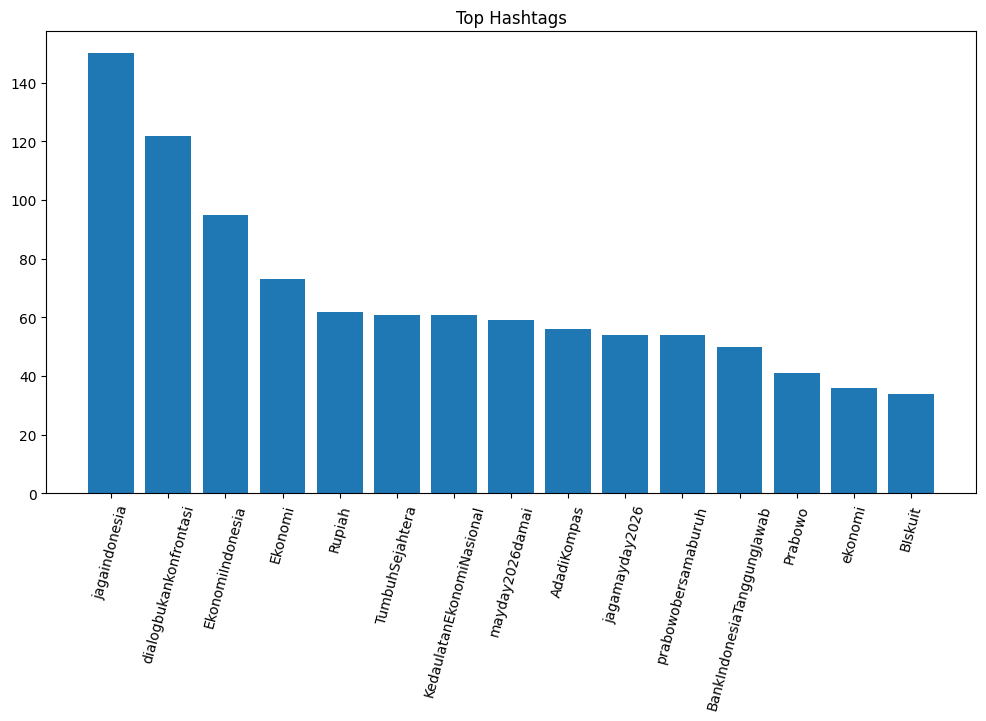

In [25]:
import re
from collections import Counter
import matplotlib.pyplot as plt

hashtags=[]

for text in df["text"]:
    
    found_hashtags=re.findall(
        r"#(\w+)",
        str(text)
    )
    
    hashtags.extend(found_hashtags)

top_hashtags= Counter(
    hashtags
).most_common(15)

tags=[x[0] for x in top_hashtags]
counts=[x[1] for x in top_hashtags]

plt.figure(figsize=(12,6))

plt.bar(tags,counts)

plt.xticks(rotation=75)

plt.title("Top Hashtags")

plt.show()